# Judge Model Training -- Multi-Class Classification (Baseline)

This notebook trains a **DistilBERT** model as a multi-class classifier to predict IMDb movie review ratings across 8 categories: `[1, 2, 3, 4, 7, 8, 9, 10]`.

This serves as the **baseline** approach. Ratings 5 and 6 are excluded to create a clearer separation between negative and positive sentiment groups.

**Architecture:** DistilBERT with an 8-class classification head.

> **Note:** The regression-based approach (`GenAi_project_regression_model_training.ipynb`) ultimately proved superior for this task and was used as the final Judge model.

## 1. Setup and Dependencies

In [ ]:
!pip install transformers datasets torch scikit-learn pandas accelerate -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 719.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 999.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Data Loading and Preprocessing

Load the IMDb dataset, filter to the 8 target ratings, map them to sequential labels (0-7), and split into train/validation sets (80/20).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. טעינת הקובץ
df = pd.read_csv('imdb_sup.csv', on_bad_lines='skip', engine='python') # וודא שהשם תואם לקובץ שהעלית

# 2. סינון הנתונים לפי המסמך
target_ratings = [1, 2, 3, 4, 7, 8, 9, 10]
df = df[df['Rating'].isin(target_ratings)].copy()

# 3. יצירת "מיפוי" לדירוגים
# המודל לא מבין ש-7 מגיע אחרי 4 בדילוג. הוא צריך מספרים מ-0 עד 7.
# אז נמיר את הדירוגים המקוריים למספרים סידוריים (Labels)
label_map = {1:0, 2:1, 3:2, 4:3, 7:4, 8:5, 9:6, 10:7}
df['label'] = df['Rating'].map(label_map)

# 4. חלוקה ל-Train ו-Test  (80/20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['Review'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

print(f"Training examples: {len(train_texts)}")
print(f"Validation examples: {len(val_texts)}")

Training examples: 33583
Validation examples: 8396


## 3. Tokenization and Dataset Preparation

Tokenize the text using DistilBERT's tokenizer (max length 256 tokens) and wrap the data in a PyTorch `Dataset` class for the Hugging Face Trainer.

In [ ]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, DistilBertTokenizerFast
# טעינת הטוקנייזר של DistilBERT
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# המרה של כל הטקסטים למספרים
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=256)

# יצירת אובייקט של Dataset שמתאים לספריית Transformers
import torch

class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

## 4. Model Initialization

Load the pre-trained DistilBERT model with an 8-class classification head and move it to GPU.

In [ ]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments

# טעינת המודל
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=8  #  יש לנו 8 מחלקות ספציפיות
)

# שליחת המודל ל-GPU
model.to('cuda')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## 5. Evaluation Metrics

Define weighted accuracy, precision, recall, and F1-score metrics to be computed at the end of each training epoch.

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# פונקציה לחישוב מדדים שתרוץ בכל סוף Epoch
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # חישוב Accuracy
    acc = accuracy_score(labels, preds)

    # חישוב Precision, Recall, F1 (weighted בגלל שיש לנו כמה מחלקות)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

## 6. Training

Train the model for up to 10 epochs with early stopping (patience=3) based on validation loss. The best model checkpoint is automatically loaded at the end.

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,              # שינוי מ-3 ל-10
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",            # מוודא בדיקה בסוף כל איפוק
    save_strategy="epoch",            # שומר Checkpoint בסוף כל איפוק
    load_best_model_at_end=True,      # טוען את המודל הכי טוב בסוף האימון
    metric_for_best_model="loss"      # המדד הקובע הוא ה-Validation Loss
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # הוספת ה-Callback כאן
)
# הפקודה שמתחילה את האימון בפועל!
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.392000,1.369472,0.460576,0.395368,0.403945,0.460576
2,1.213700,1.339299,0.477727,0.441789,0.522013,0.477727
3,0.986000,1.509574,0.470819,0.453774,0.453300,0.470819
4,0.777600,1.646584,0.441520,0.447088,0.461716,0.441520
5,0.563300,1.951281,0.445212,0.452069,0.467776,0.445212


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


TrainOutput(global_step=10495, training_loss=0.9721688781709203, metrics={'train_runtime': 4147.4197, 'train_samples_per_second': 80.973, 'train_steps_per_second': 5.061, 'total_flos': 1.112282165372928e+16, 'train_loss': 0.9721688781709203, 'epoch': 5.0})

## 7. Evaluation -- Confusion Matrix

Generate predictions on the validation set and visualize the confusion matrix to assess per-rating classification performance.

Generating predictions for Confusion Matrix...


<Figure size 1000x1000 with 0 Axes>

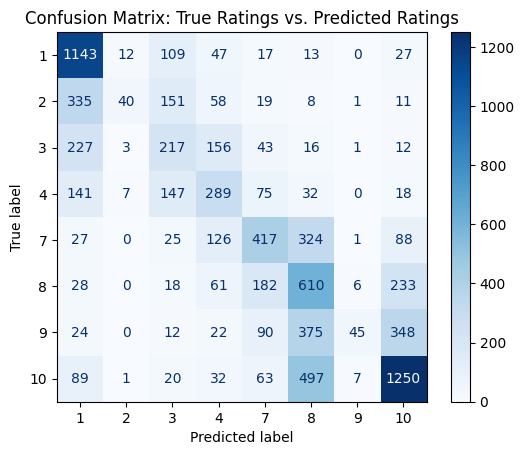

In [ ]:
# 1. ביצוע תחזיות על סט ה-Validation
print("Generating predictions for Confusion Matrix...")
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# 2. הגדרת השמות האמיתיים של הדירוגים (כדי שבגרף יופיע 1,2,3 ולא 0,1,2)
class_names = [1, 2, 3, 4, 7, 8, 9, 10]

# 3. יצירת המטריצה וציור הגרף
cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# הגדרת גודל הגרף
plt.figure(figsize=(10, 10))
# ציור הגרף בצבעים כחולים
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title("Confusion Matrix: True Ratings vs. Predicted Ratings")
plt.show()

## 8. Save Model

Save the trained model and tokenizer for later use in the generation pipeline.

In [ ]:
# שמירת המודל והטוקנייזר לשימוש עתידי
model.save_pretrained("./my_imdb_judge")
tokenizer.save_pretrained("./my_imdb_judge")

print("The Judge is ready and saved!")

The Judge is ready and saved!
